In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pi = 95

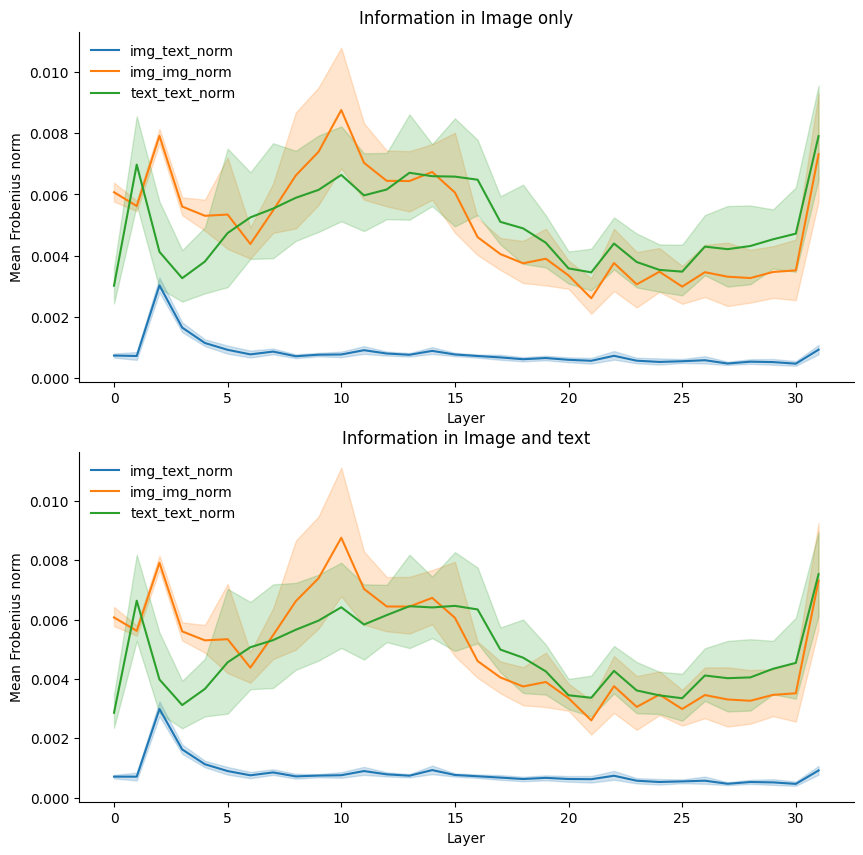

In [3]:
fig,ax = plt.subplots(2,1,figsize=(10,10))
target = 'gray_cylinder'
nobjects = 7

results_path = f'./results/llava7B/attention/image/frobenius_attention_matrix_{target}_{nobjects}.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[0] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Information in Image only')

results_path = f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Information in Image and text')


b.legend(frameon=False)
sns.despine(top=True, right=True)

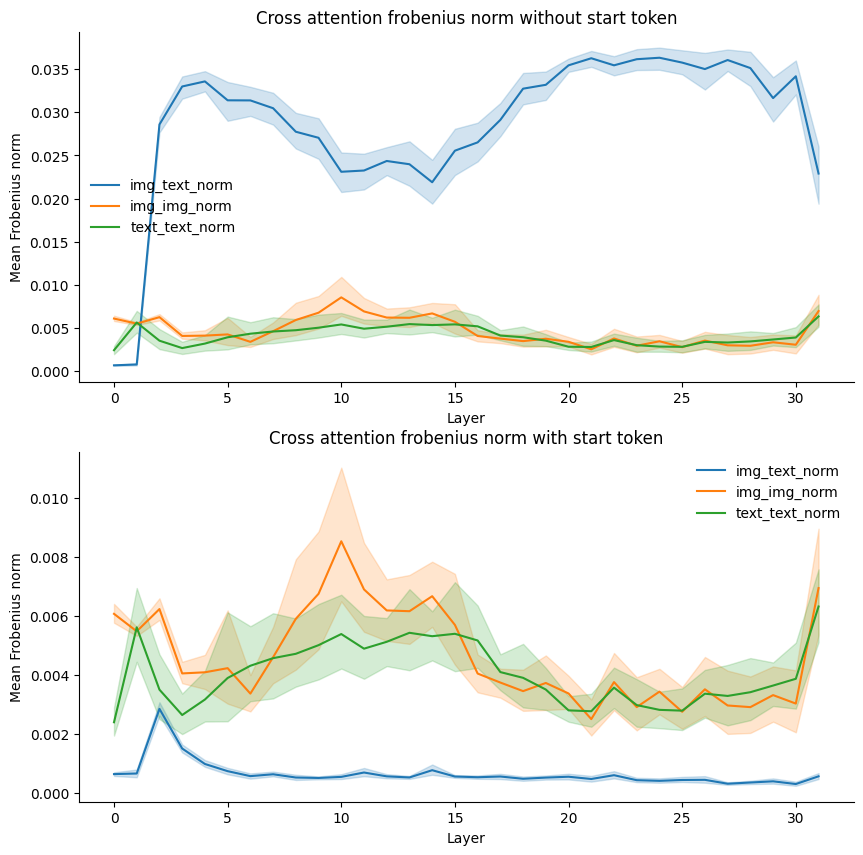

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(10,10))
target = 'gray_cylinder_metal'
nobjects = 10

results_path = f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}_wstart_token.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[0] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Cross attention frobenius norm with start token')

results_path = f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}_wostart_token.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Cross attention frobenius norm without start token')


b.legend(frameon=False)
sns.despine(top=True, right=True)

In [42]:
attn_mat = np.load(f'./results/llava7B/attention/image_and_text/frobenius_attention_matrix_{target}_{nobjects}.npy')
attn_mat = np.log10(attn_mat)

/tmp/ipykernel_25501/2788562999.py:2: RuntimeWarning: divide by zero encountered in log10
  attn_mat = np.log10(attn_mat)


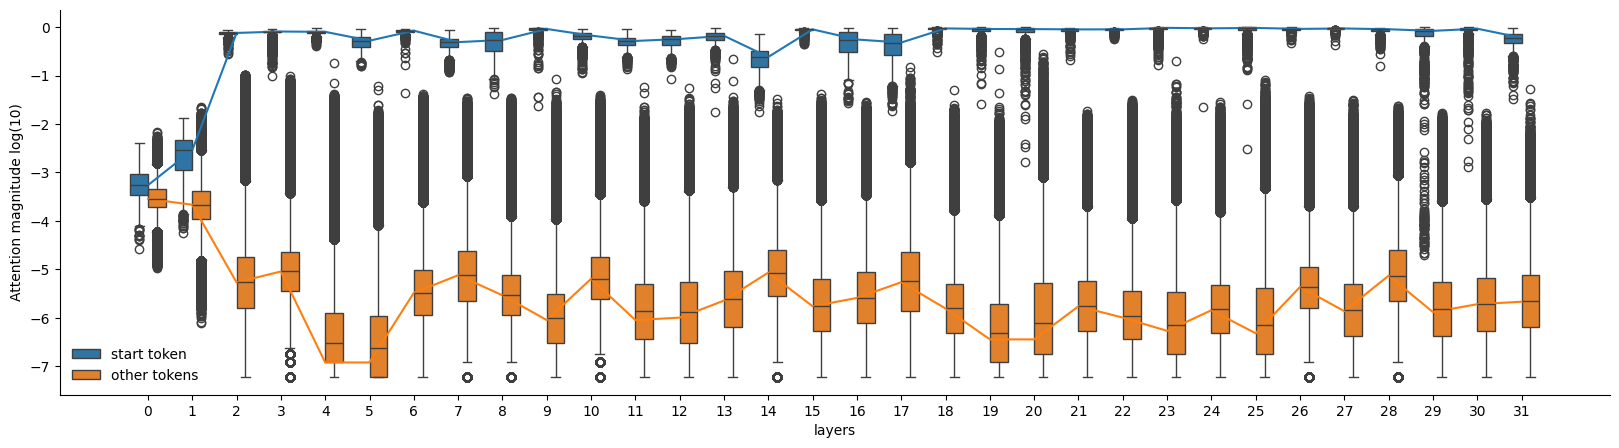

In [44]:
fig,ax = plt.subplots(1,1,figsize=(20, 5))
for i in range(attn_mat.shape[0]):
    plot_df = pd.DataFrame({
    'magnitude': np.append(attn_mat[i,0,:,0].reshape(-1),  attn_mat[i,0,:,1:].reshape(-1)),
    'layer': ['start token']*len(attn_mat[i,0,:,0].reshape(-1)) + ['other tokens']*len(attn_mat[i,0,:,1:].reshape(-1))
    })

    if i==0:
        b = sns.boxplot(data=plot_df,
                        x=i,
                        ax=ax,
                        y='magnitude',
                        hue='layer')
    else:
        b = sns.boxplot(data=plot_df,
                        x=i,
                        ax=ax,
                        legend=False,
                        y='magnitude',
                        hue='layer')
    b.legend(frameon=False)


plot_df = pd.DataFrame({
                        'magnitude': np.append(np.median(attn_mat[:,0,:,0], axis=1),  np.median(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1), axis=-1)),
                        'hue': ['start token']*len(np.median(attn_mat[:,0,:,0], axis=1)) + ['other tokens']*len(np.median(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1),axis=-1)),
                        'layer': list(range(len(attn_mat[:,0,:,0].mean(axis=1)))) + list(range(len(attn_mat[:,0,:,1:].reshape(attn_mat.shape[0],-1).mean(axis=-1))))
                        })
b=sns.lineplot(data=plot_df,y='magnitude',ax=ax,
                        x='layer', hue='hue', legend=False)
b.set_ylabel('Attention magnitude log(10)')
b.set_xlabel('layers')

sns.despine(top=True, right=True)
        

        
    


Text(0.5, 1.0, 'Entropy')

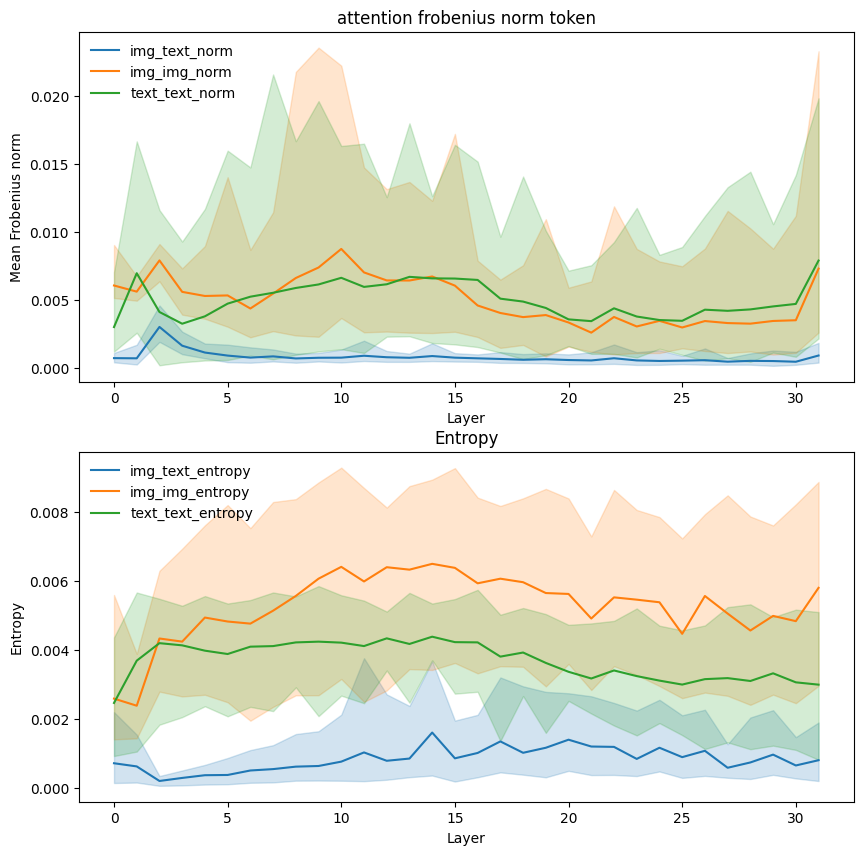

In [2]:
fig,ax = plt.subplots(2,1,figsize=(10,10))
target = 'gray_cylinder'
nobjects = 7

mode = 'image'

results_path = f'./results/llava7B/attention/frobenius_attention_matrix_{mode}_{target}_{nobjects}.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)


b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('attention frobenius norm token')
        
results_path = f'./results/llava7B/attention/entropy_attention_matrix_{mode}_{target}_{nobjects}.csv'
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


Text(0.5, 1.0, 'Entropy')

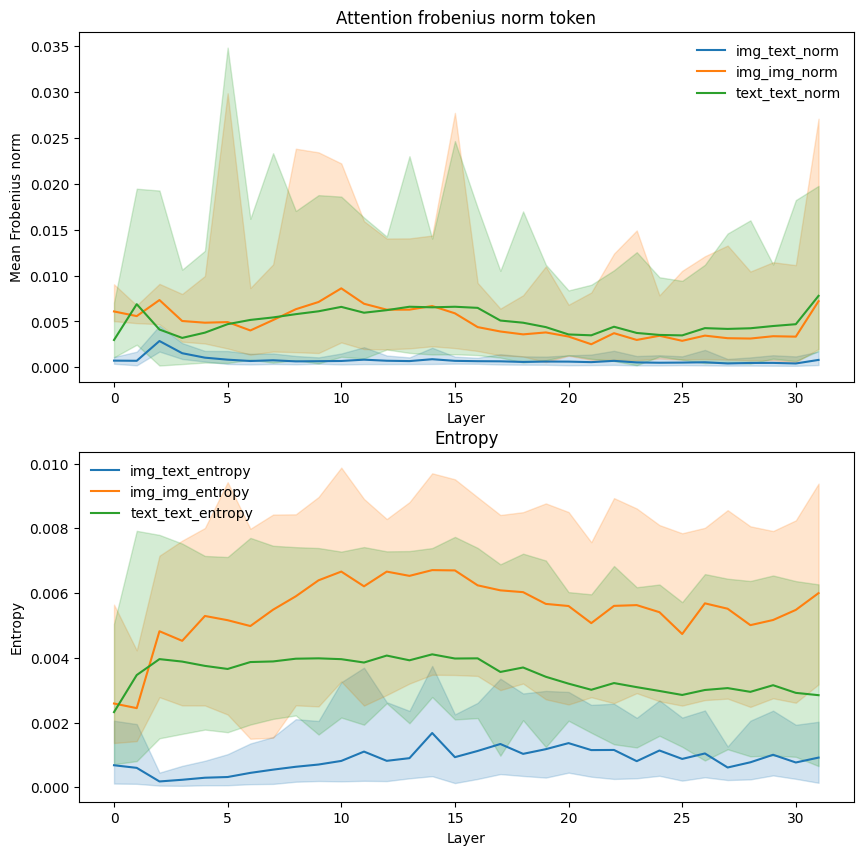

In [25]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/llava7B/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results/llava7B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results/llava7B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


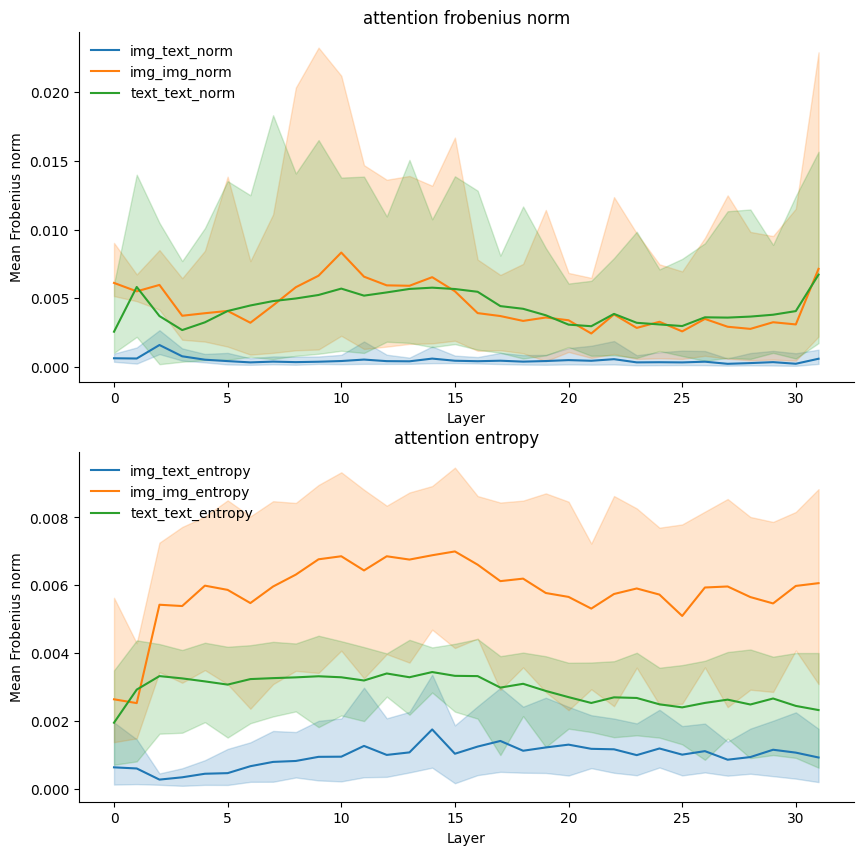

In [16]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

results_path = f"./results/llava7B/attention/original_prompt_frobenius_attention_matrix.csv"
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)


b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('attention frobenius norm')

results_path = f"./results/llava7B/attention/original_prompt_entropy_attention_matrix.csv"
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)
b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('attention entropy')


b.legend(frameon=False)
sns.despine(top=True, right=True)

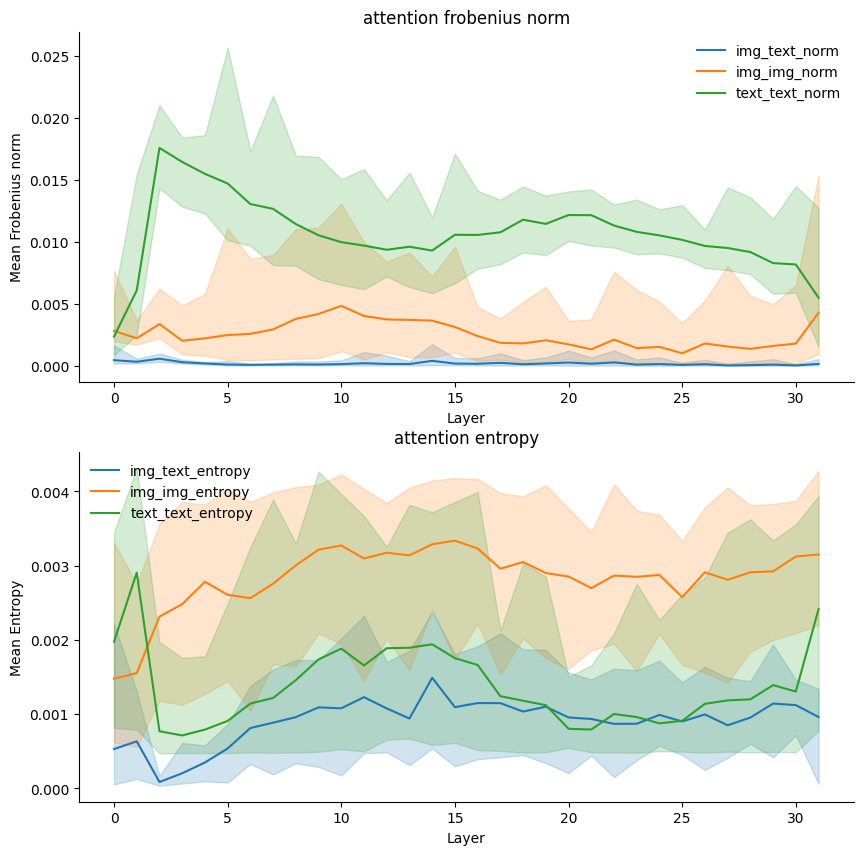

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

results_path = f"./results/llava1.6_vicuna/attention/frobenius_attention_matrix_image_and_text_gray_cylinder_7.csv"
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)


b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('attention frobenius norm')

results_path = f"./results/llava1.6_vicuna/attention//entropy_attention_matrix_image_and_text_gray_cylinder_7.csv"
plot_df = pd.read_csv(results_path, index_col=0)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)
b.set_xlabel('Layer')
b.set_ylabel('Mean Entropy')
b.legend(frameon=False)
b.set_title('attention entropy')


b.legend(frameon=False)
sns.despine(top=True, right=True)

Text(0.5, 1.0, 'Entropy')

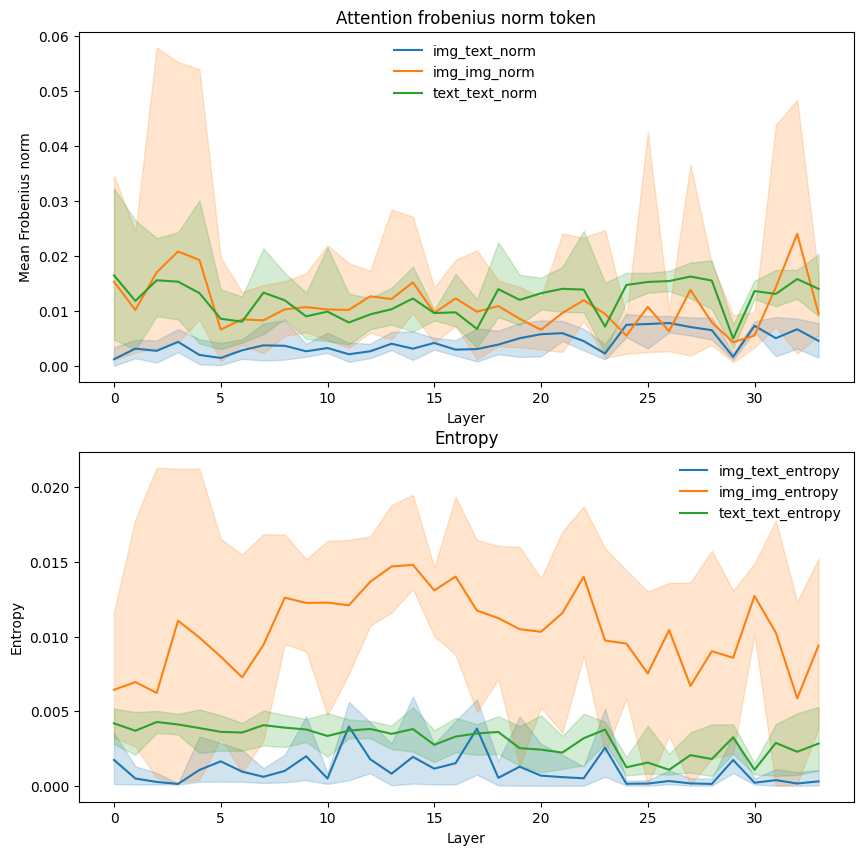

In [4]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/gemma3-4B/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results/gemma3-4B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results/gemma3-4B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


Text(0.5, 1.0, 'Entropy')

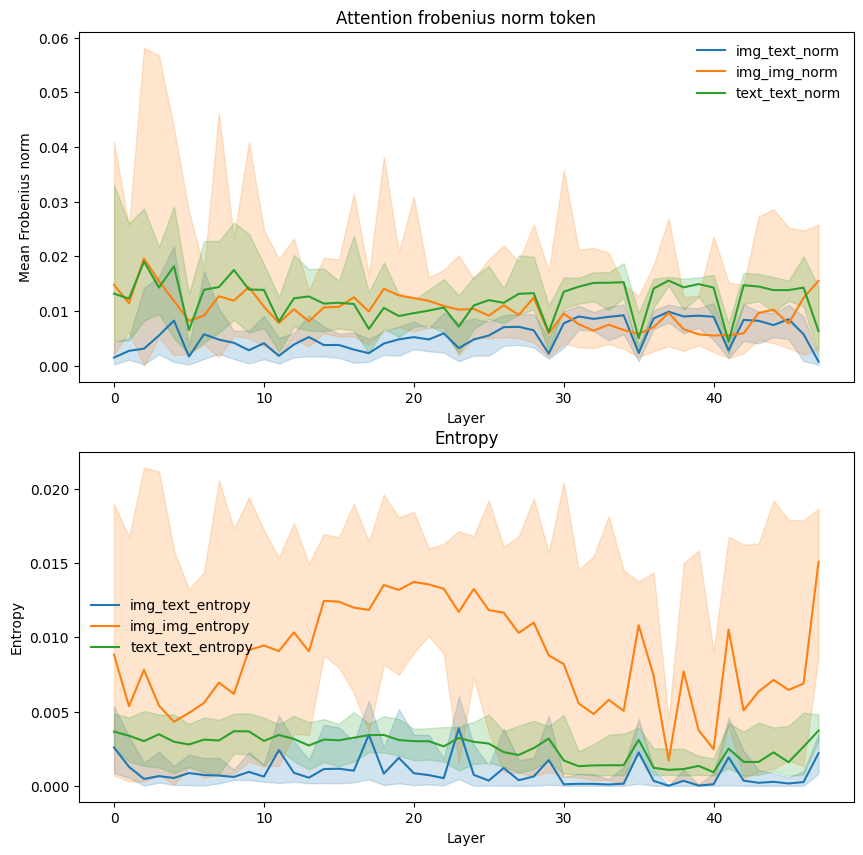

In [6]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/gemma3-12B/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results/gemma3-12B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results/gemma3-12B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


Text(0.5, 1.0, 'Entropy')

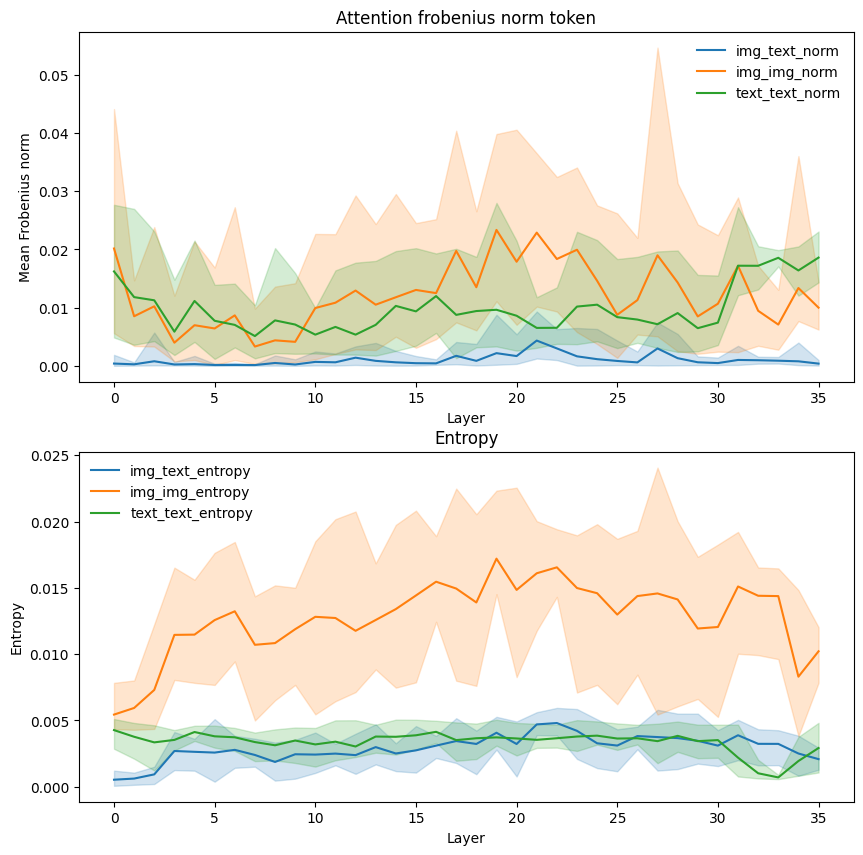

In [7]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/qwen2.5_3B/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results//qwen2.5_3B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results//qwen2.5_3B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


Text(0.5, 1.0, 'Entropy')

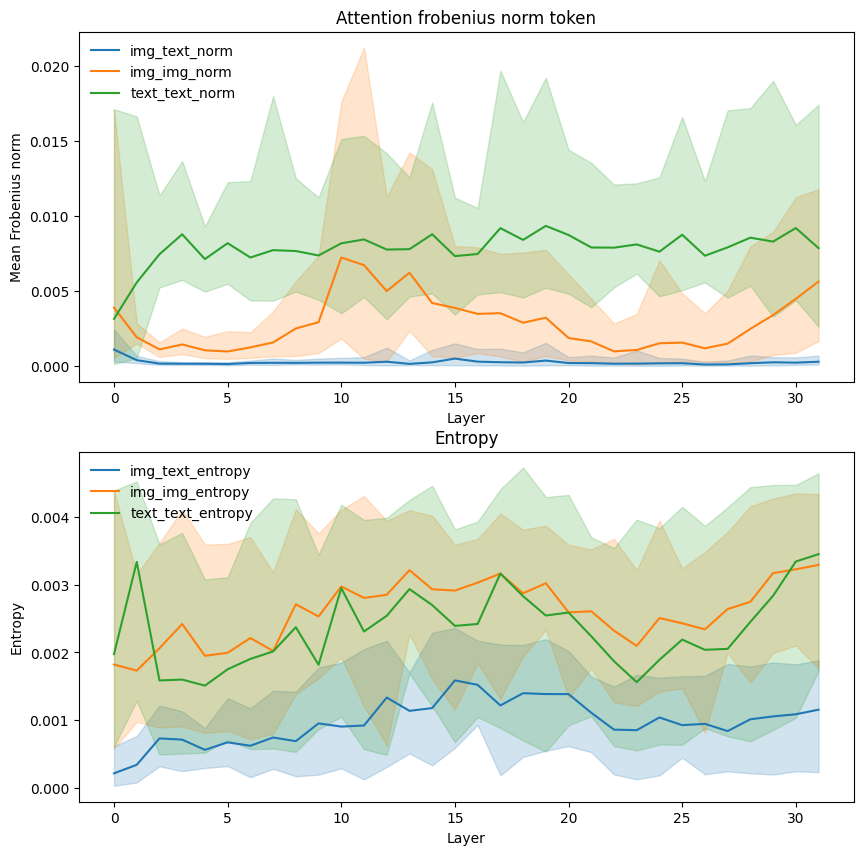

In [5]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/llava1.6_mistral/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results/llava1.6_mistral/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results/llava1.6_mistral/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


Text(0.5, 1.0, 'Entropy')

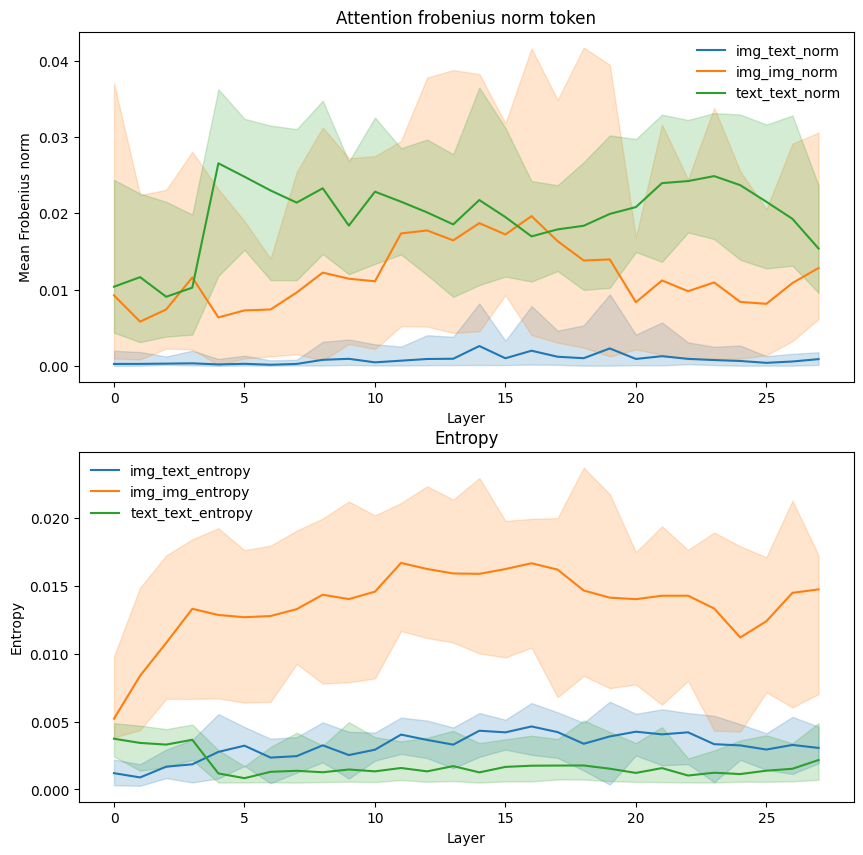

In [37]:
fig,ax = plt.subplots(2,1,figsize=(10,10))

files = os.listdir(f'./results/qwen2.5_7B/attention/')
plot_df = []
for f in files:
    if '.csv' in f and 'frobenius' in f:
        df_ = pd.read_csv(f'./results/qwen2.5_7B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='attention_matrix',
    hue_order=['img_text_norm', 'img_img_norm', 'text_text_norm'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[0] 
)



b.set_xlabel('Layer')
b.set_ylabel('Mean Frobenius norm')
b.legend(frameon=False)
b.set_title('Attention frobenius norm token')
        
plot_df = []
for f in files:
    if '.csv' in f and 'entropy' in f:
        df_ = pd.read_csv(f'./results/qwen2.5_7B/attention/{f}', index_col=0)
        plot_df = plot_df + [df_]

plot_df = pd.concat(plot_df)

b = sns.lineplot(
    data=plot_df,
    x='variable',
    y='value',
    hue='entropy',
    hue_order=['img_text_entropy', 'img_img_entropy', 'text_text_entropy'],
    errorbar=("pi", pi),
    # style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.legend(frameon=False)
b.set_title('Entropy')


llava7B entropy auc:  0.026643336513293682
llava7B fro auc:  0.022308002864890448
llava1.6_vicuna entropy auc:  0.028249973721192076
llava1.6_vicuna fro auc:  0.006356559721296548
llava1.6_mistral entropy auc:  0.03032605086257329
llava1.6_mistral fro auc:  0.007692952553568407
gemma3-4B entropy auc:  0.034236522484283285
gemma3-4B fro auc:  0.14059030315354124
gemma3-12B entropy auc:  0.040759807406243145
gemma3-12B fro auc:  0.26219340834046617
qwen2.5_3B entropy auc:  0.10376334903723476
qwen2.5_3B fro auc:  0.035466344245610106
qwen2.5_7B entropy auc:  0.08699881465191366
qwen2.5_7B fro auc:  0.02280483463996648


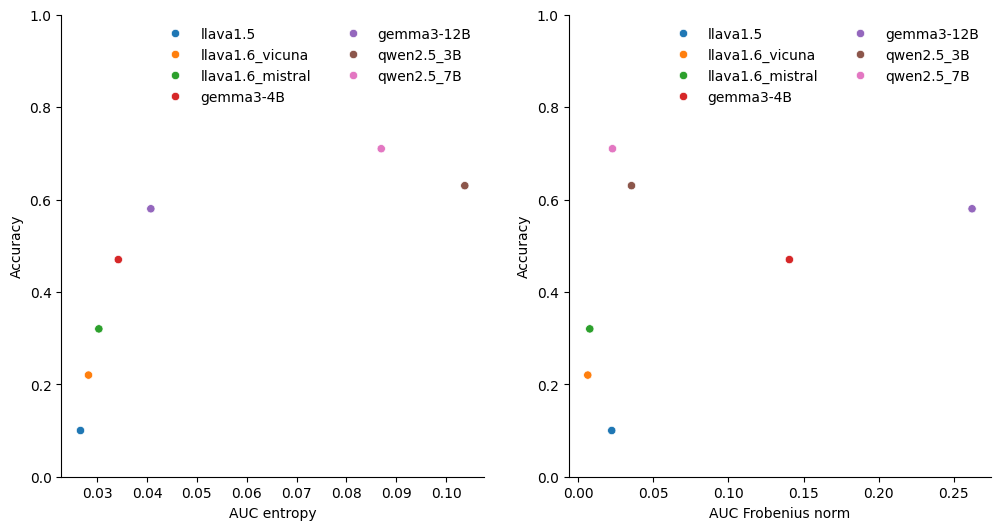

In [43]:
import sklearn
model_ls = ['llava7B', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
auc_entropy_ls = []
auc_fro_ls = []

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

for ax_idx, model in enumerate(model_ls):
    path = f'./results/{model}/attention/'

    files_entropy = [i for i in os.listdir(path) if '.csv' in i and 'entropy' in i]
    files_fro = [i for i in os.listdir(path) if '.csv' in i and 'frobenius' in i]

    # Entropy
    plot_df = []
    for idx, f in enumerate(files_entropy):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["entropy", "variable"]).mean(numeric_only=True).reset_index()
    auc_text_img = sklearn.metrics.auc(mean_df[mean_df['entropy']=='img_text_entropy']['variable'], 
                                mean_df[mean_df['entropy']=='img_text_entropy']['value'])

    print(f"{model} entropy auc: ", auc_text_img)
    auc_entropy_ls = auc_entropy_ls + [auc_text_img]

    # Frobenius norm
    plot_df = []
    for idx, f in enumerate(files_fro):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["attention_matrix", "variable"]).mean(numeric_only=True).reset_index()
    auc_text_img = sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='img_text_norm']['variable'], 
                                mean_df[mean_df['attention_matrix']=='img_text_norm']['value'])

    print(f"{model} fro auc: ", auc_text_img)
    auc_fro_ls = auc_fro_ls + [auc_text_img]

acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B','qwen2.5_7B']
b = sns.scatterplot(x=auc_entropy_ls, y=acc_ls, hue=model_ls,ax=ax[0])
b.set_xlabel('AUC entropy')
b.set_ylabel("Accuracy")
b.legend(frameon=False, ncols=2)
b.set(ylim=(0,1))

b = sns.scatterplot(x=auc_fro_ls, y=acc_ls, hue=model_ls,ax=ax[1])
b.set_xlabel('AUC Frobenius norm')
b.set_ylabel("Accuracy")
b.set(ylim=(0,1))
b.legend(frameon=False, ncols=2)

sns.despine(top=True, right=True)

llava7B entropy auc:  -0.08038662022442486
llava7B fro auc:  -0.12847308505782085
llava1.6_vicuna entropy auc:  -0.013389877582266785
llava1.6_vicuna fro auc:  -0.3307310020373081
llava1.6_mistral entropy auc:  -0.04214175751452439
llava1.6_mistral fro auc:  -0.23842195788904894
gemma3-4B entropy auc:  -0.06687013282001547
gemma3-4B fro auc:  -0.25742739889028454
gemma3-12B entropy auc:  -0.07951789540012909
gemma3-12B fro auc:  -0.3175535364373721
qwen2.5_3B entropy auc:  -0.014184689877303147
qwen2.5_3B fro auc:  -0.29895965994494783
qwen2.5_7B entropy auc:  0.04146261023466981
qwen2.5_7B fro auc:  -0.51397488965733


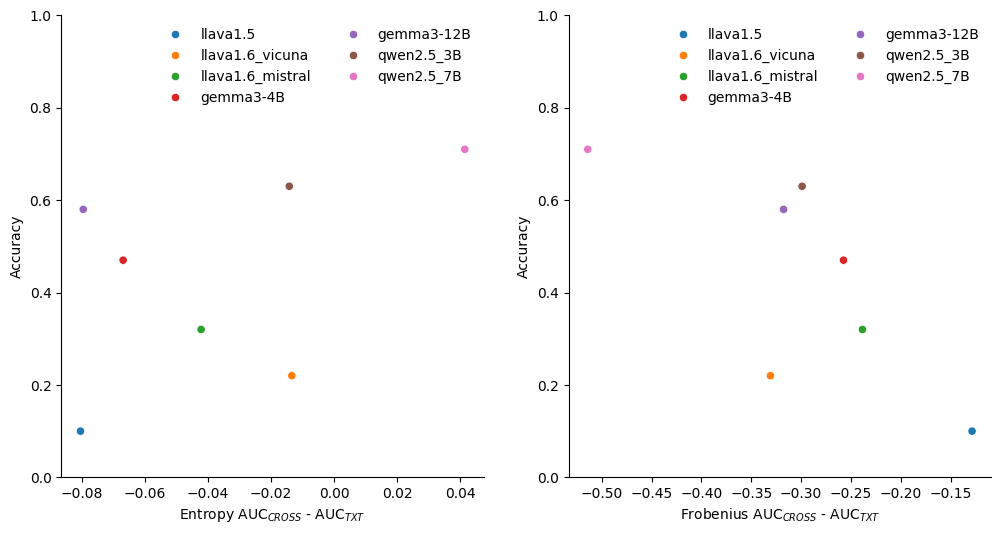

In [47]:
import sklearn
model_ls = ['llava7B', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
auc_entropy_ls = []
auc_fro_ls = []

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

for ax_idx, model in enumerate(model_ls):
    path = f'./results/{model}/attention/'

    files_entropy = [i for i in os.listdir(path) if '.csv' in i and 'entropy' in i]
    files_fro = [i for i in os.listdir(path) if '.csv' in i and 'frobenius' in i]

    # Entropy
    plot_df = []
    for idx, f in enumerate(files_entropy):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["entropy", "variable"]).mean(numeric_only=True).reset_index()
    auc_diff = sklearn.metrics.auc(mean_df[mean_df['entropy']=='img_text_entropy']['variable'], 
                                mean_df[mean_df['entropy']=='img_text_entropy']['value'])
    
    auc_diff = auc_diff - sklearn.metrics.auc(mean_df[mean_df['entropy']=='text_text_entropy']['variable'], 
                                    mean_df[mean_df['entropy']=='text_text_entropy']['value'])

    print(f"{model} entropy auc: ", auc_diff)
    auc_entropy_ls = auc_entropy_ls + [auc_diff]

    # Frobenius norm
    plot_df = []
    for idx, f in enumerate(files_fro):
        df_ = pd.read_csv(path+f, index_col=0)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["attention_matrix", "variable"]).mean(numeric_only=True).reset_index()
    auc_diff = sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='img_text_norm']['variable'], 
                                mean_df[mean_df['attention_matrix']=='img_text_norm']['value'])
    
    auc_diff = auc_diff - sklearn.metrics.auc(mean_df[mean_df['attention_matrix']=='text_text_norm']['variable'], 
                                                mean_df[mean_df['attention_matrix']=='text_text_norm']['value'])

    print(f"{model} fro auc: ", auc_diff)
    auc_fro_ls = auc_fro_ls + [auc_diff]

acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B','qwen2.5_7B']
b = sns.scatterplot(x=auc_entropy_ls, y=acc_ls, hue=model_ls,ax=ax[0])
b.set_xlabel('Entropy AUC$_{CROSS}$ - AUC$_{TXT}$')
b.set_ylabel("Accuracy")
b.legend(frameon=False, ncols=2)
b.set(ylim=(0,1))

b = sns.scatterplot(x=auc_fro_ls, y=acc_ls, hue=model_ls,ax=ax[1])
b.set_xlabel('Frobenius AUC$_{CROSS}$ - AUC$_{TXT}$')
b.set_ylabel("Accuracy")
b.set(ylim=(0,1))
b.legend(frameon=False, ncols=2)

sns.despine(top=True, right=True)